# EKARUS error budget

Wavefront residuals versus flux for each stored pair of mode count and maximum frequency, then the 650 nm Strehl for four of those pairs overlaid in one figure.

Tables are read from `/raid1/mmenessini/results/EKARUS/eb_csv`. CSV names follow

`eb_ekarus_rMod{rMod:.1f}_max{maxFreq}Hz_{nmodes}modes_delay{tau_ms:.2f}ms_V{wind}mps.csv`

with `rMod`, delay, wind speed, mode count, and maximum frequency taken from the file name. Numpy and pickle dictionaries in that same directory are loaded too. The notebook uses numpy, matplotlib, and the standard library only.

Each residual figure is a 3×3 grid. Columns are seeing 1.0, 1.5 and 2.0 arcsec. Rows are wind 3, 5 and 7 m/s. Fitting, noise, lag and aliasing are plotted in nm, and total is the root-sum-square of those four. The x-axis is flux in phot/pix/ms, computed from magnitude with `get_flux` and divided by `N_PIX`; stored photon values are divided by `N_PIX` when magnitude is unavailable. Flux uses a logarithmic axis. If a requested seeing or wind is not in the table, the closest stored value is drawn and the figure title says so. A panel with no stored grid is left empty.

The Strehl cell overlays `(200, 500)`, `(200, 900)`, `(350, 500)` and `(350, 900)` modes and hertz in one 3×3 figure, with a distinct color and legend label for each pair. The x-axis uses the same flux units. Strehl is `exp(-sigma**2)` with `sigma = 2*pi*res_tot/650` and `res_tot` the RSS residual in nm, so `sigma` is in radians. Residuals whose median absolute value is below 10⁻³ are treated as metres and scaled to nm before that ratio.

Skipping eb_ekarus_baseline_rMod5.0_delay1.50ms_bin1.csv: CSV name is not eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps
Skipping eb_ekarus_best_rMod5.0_delay0.50ms_bin1.csv: CSV name is not eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps
Skipping eb_ekarus_best_rMod5.0_delay0.50ms_bin2.csv: CSV name is not eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps
Skipping eb_ekarus_best_rMod5.0_delay0.50ms_bin3.csv: CSV name is not eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps
Skipping eb_ekarus_best_rMod5.0_delay0.50ms_bin4.csv: CSV name is not eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps
Skipping eb_ekarus_goal_rMod5.0_delay1.00ms_bin1.csv: CSV name is not eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps
Skipping eb_ekarus_goal_rMod5.0_delay1.00ms_bin2.csv: CSV name is not eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps
Skipping eb_ekarus_rMod5.0_200modes_delay1.10ms_V3mps.csv: CSV name is not eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps
Skipping eb_ekarus_rMod5.0_200modes_delay1.10ms_V5mps.csv: CSV name is 

200 modes, maximum frequency 500 Hz
200 modes, maximum frequency 700 Hz
200 modes, maximum frequency 900 Hz
250 modes, maximum frequency 500 Hz
250 modes, maximum frequency 700 Hz
250 modes, maximum frequency 900 Hz
300 modes, maximum frequency 500 Hz
300 modes, maximum frequency 700 Hz
300 modes, maximum frequency 900 Hz
350 modes, maximum frequency 500 Hz
350 modes, maximum frequency 700 Hz
350 modes, maximum frequency 900 Hz


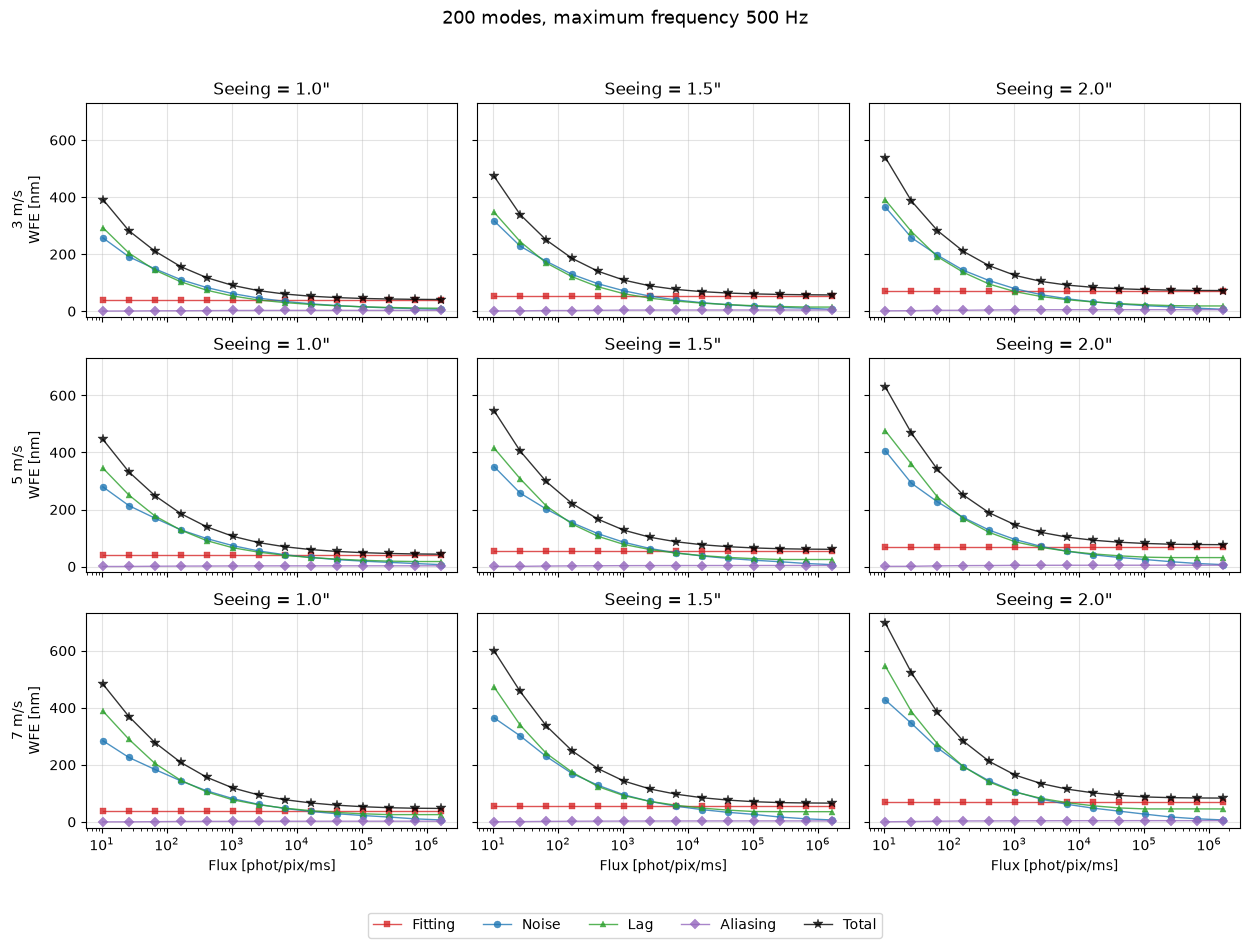

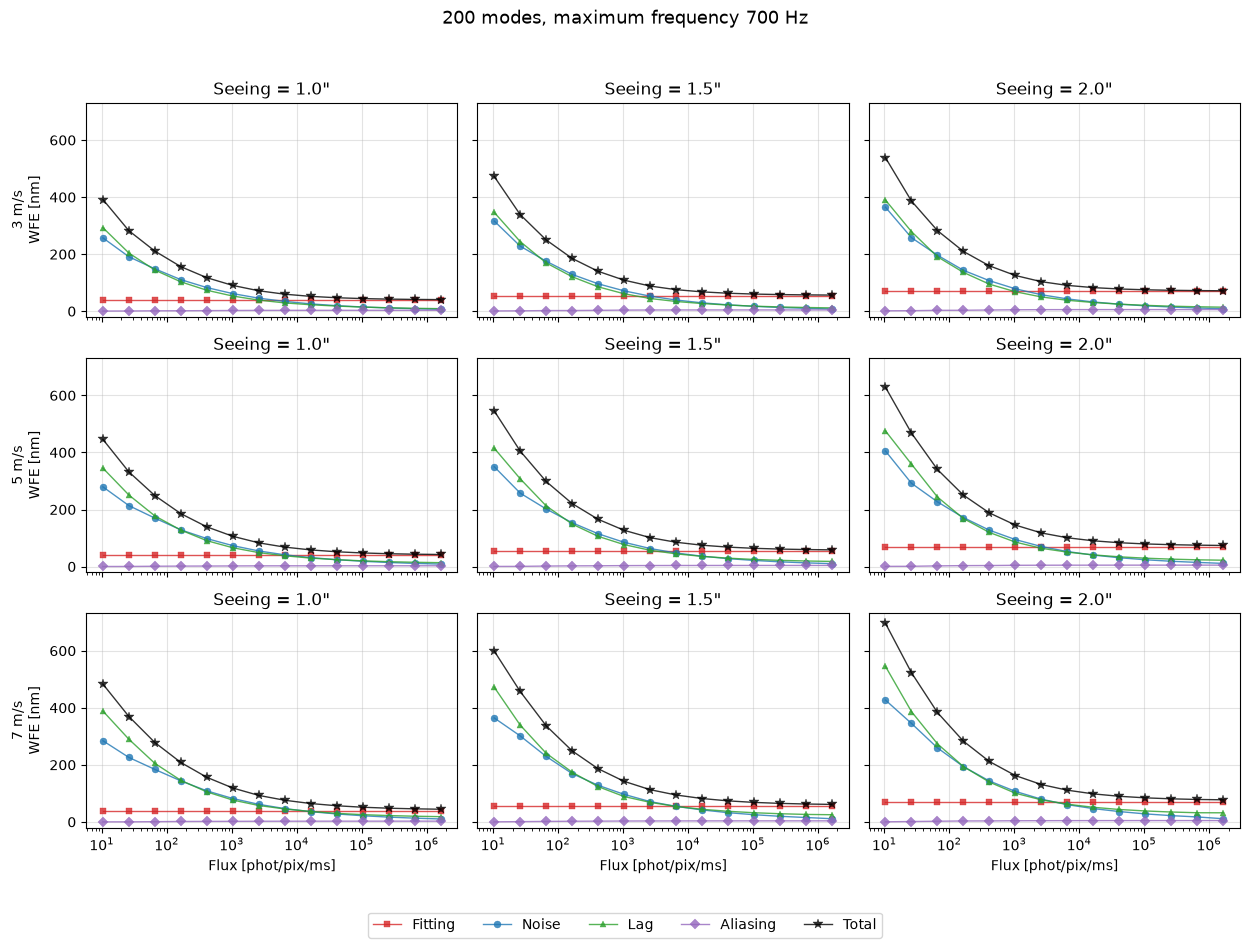

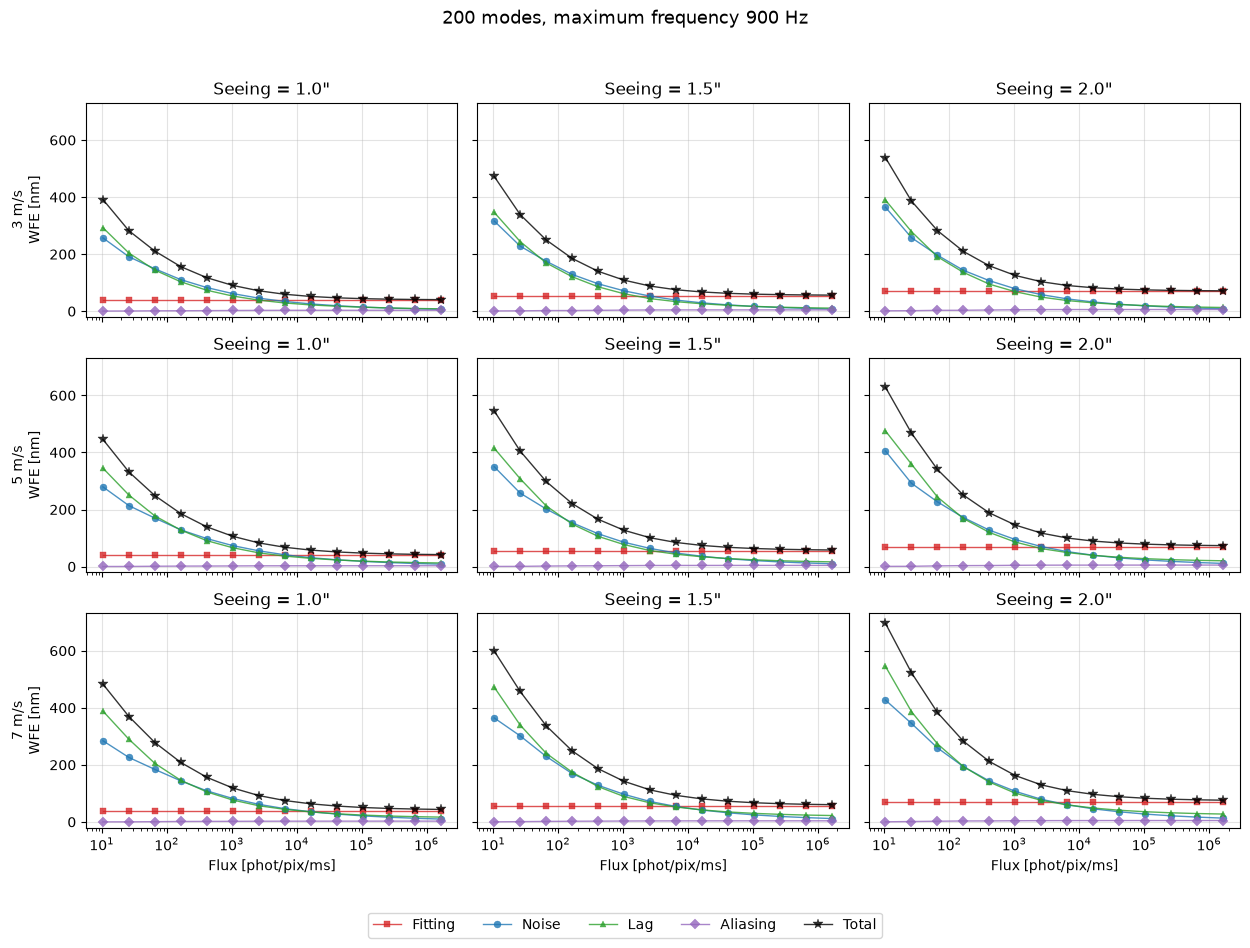

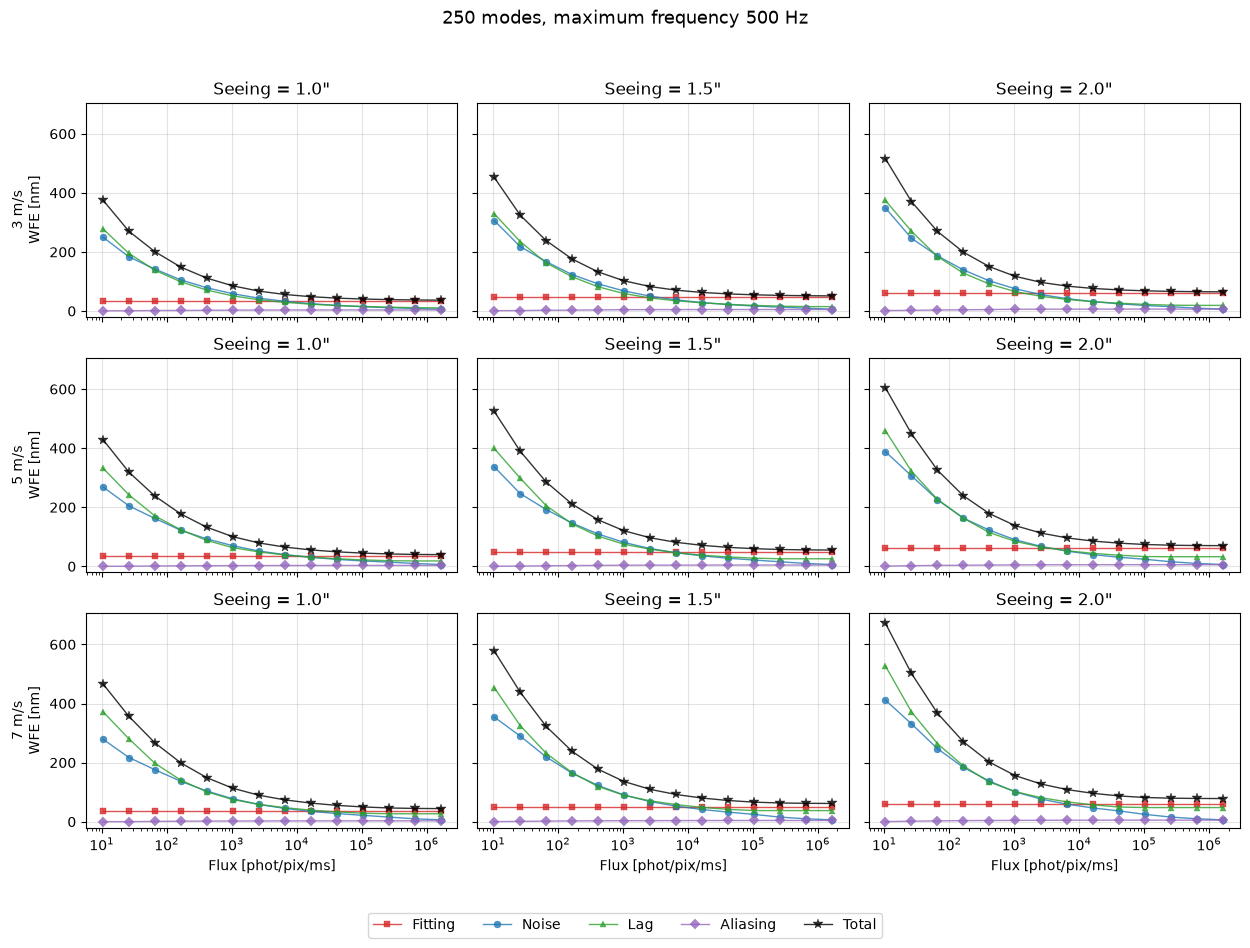

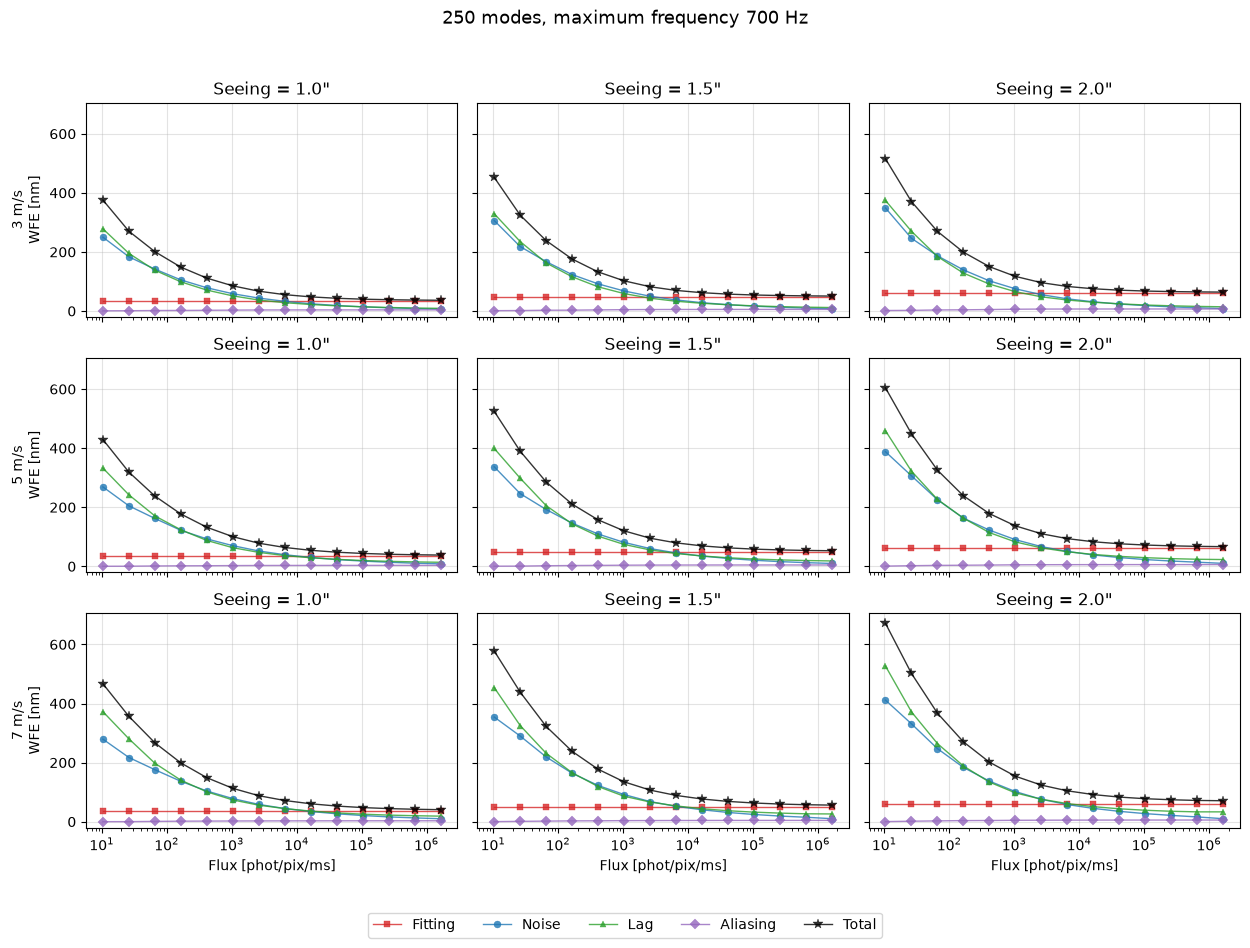

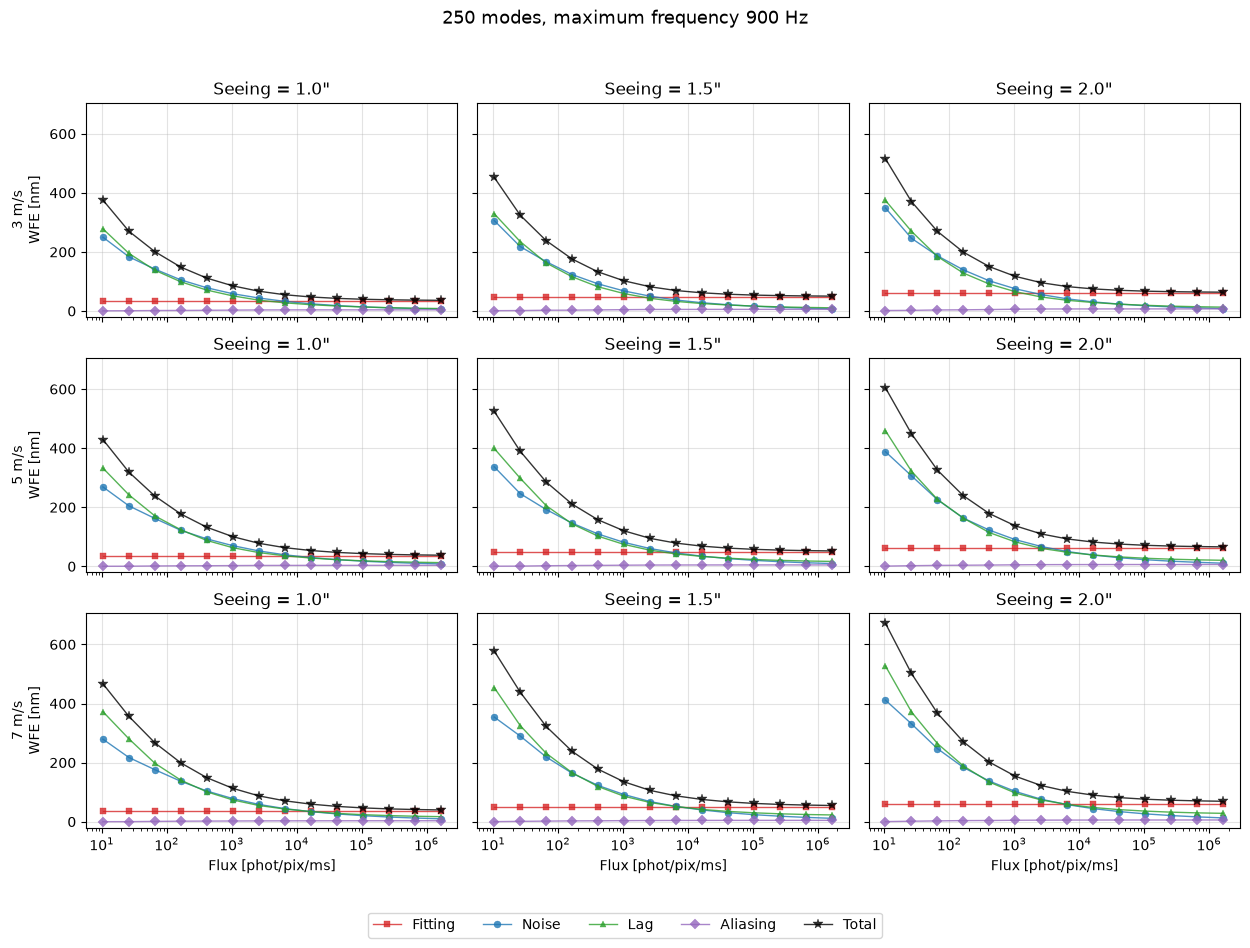

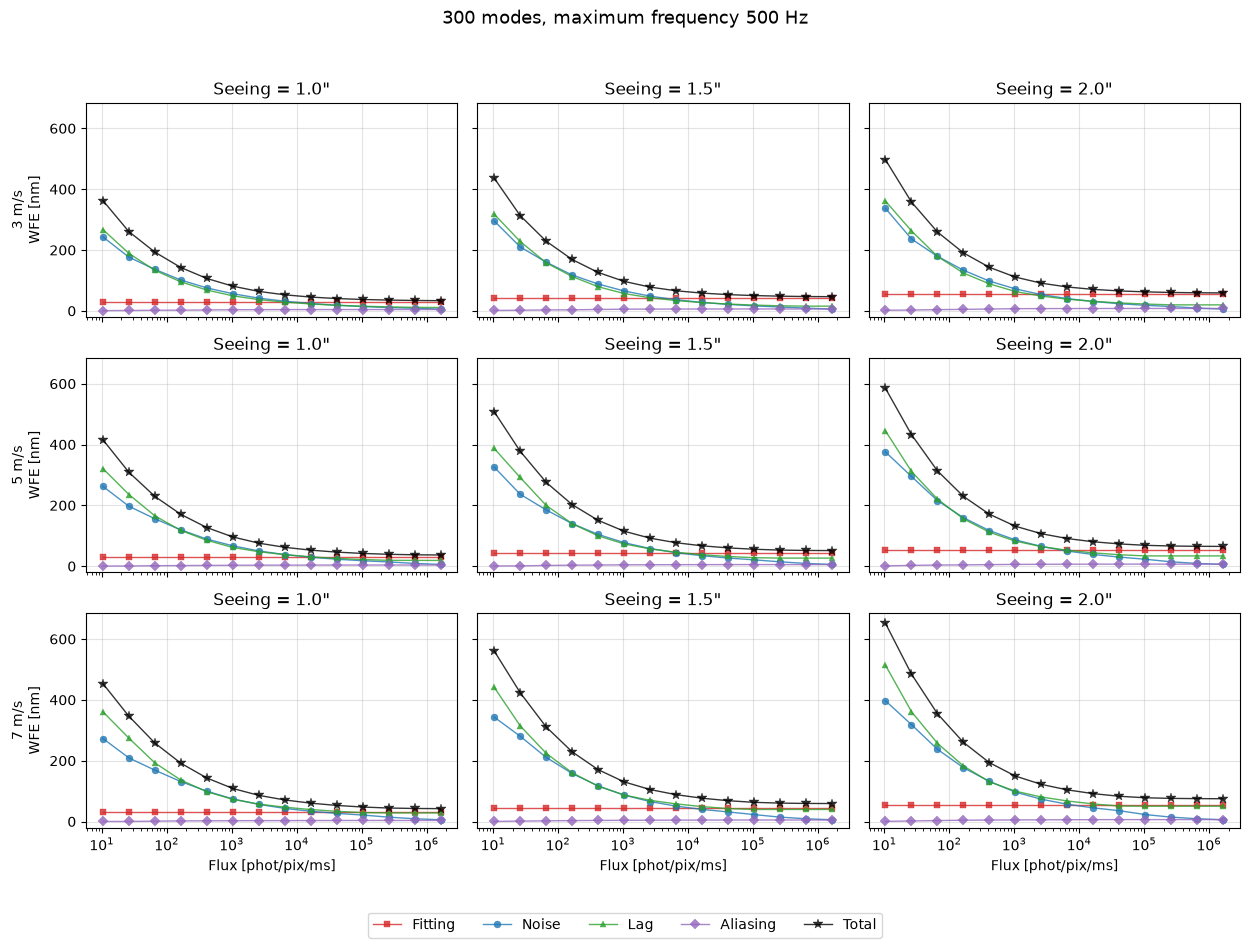

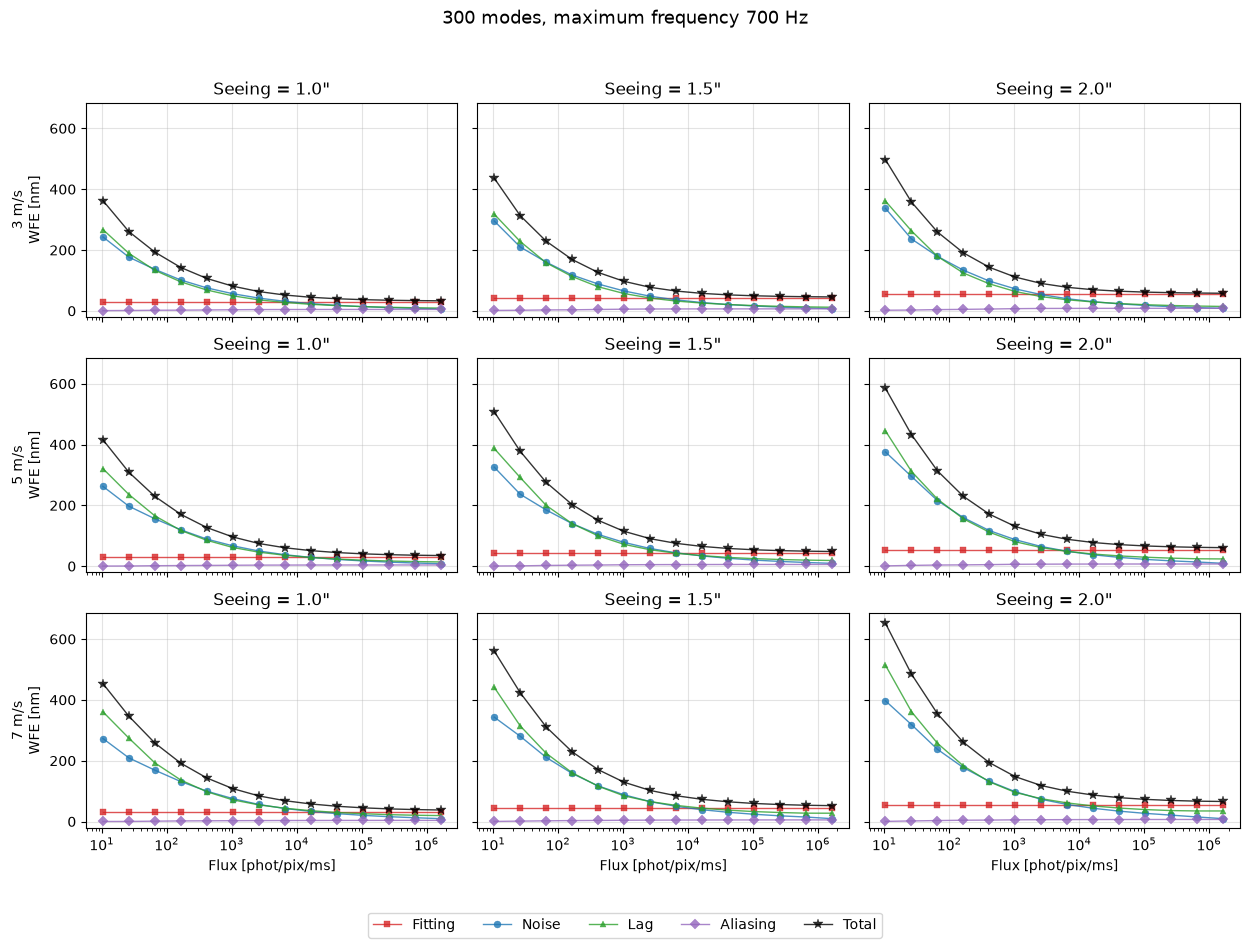

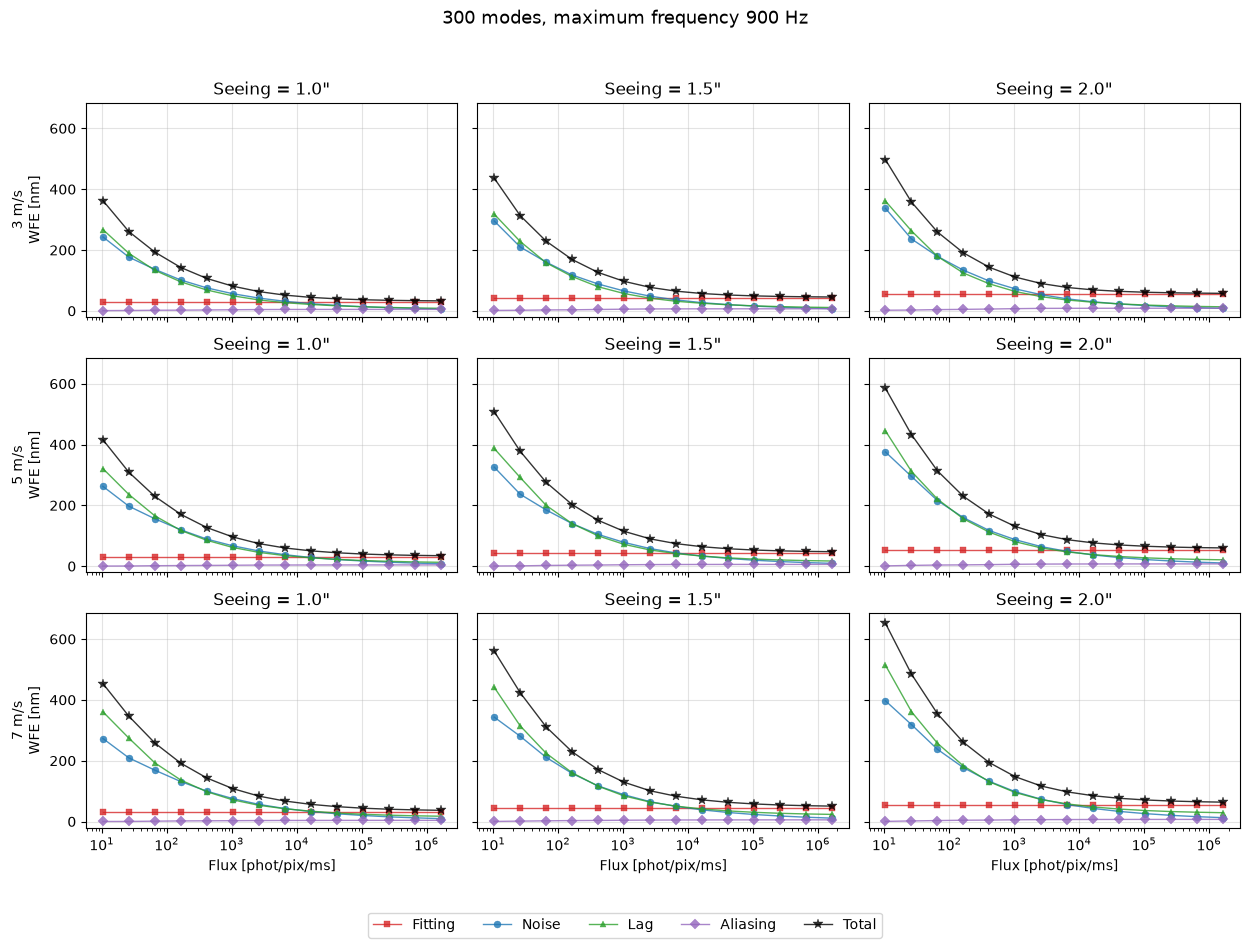

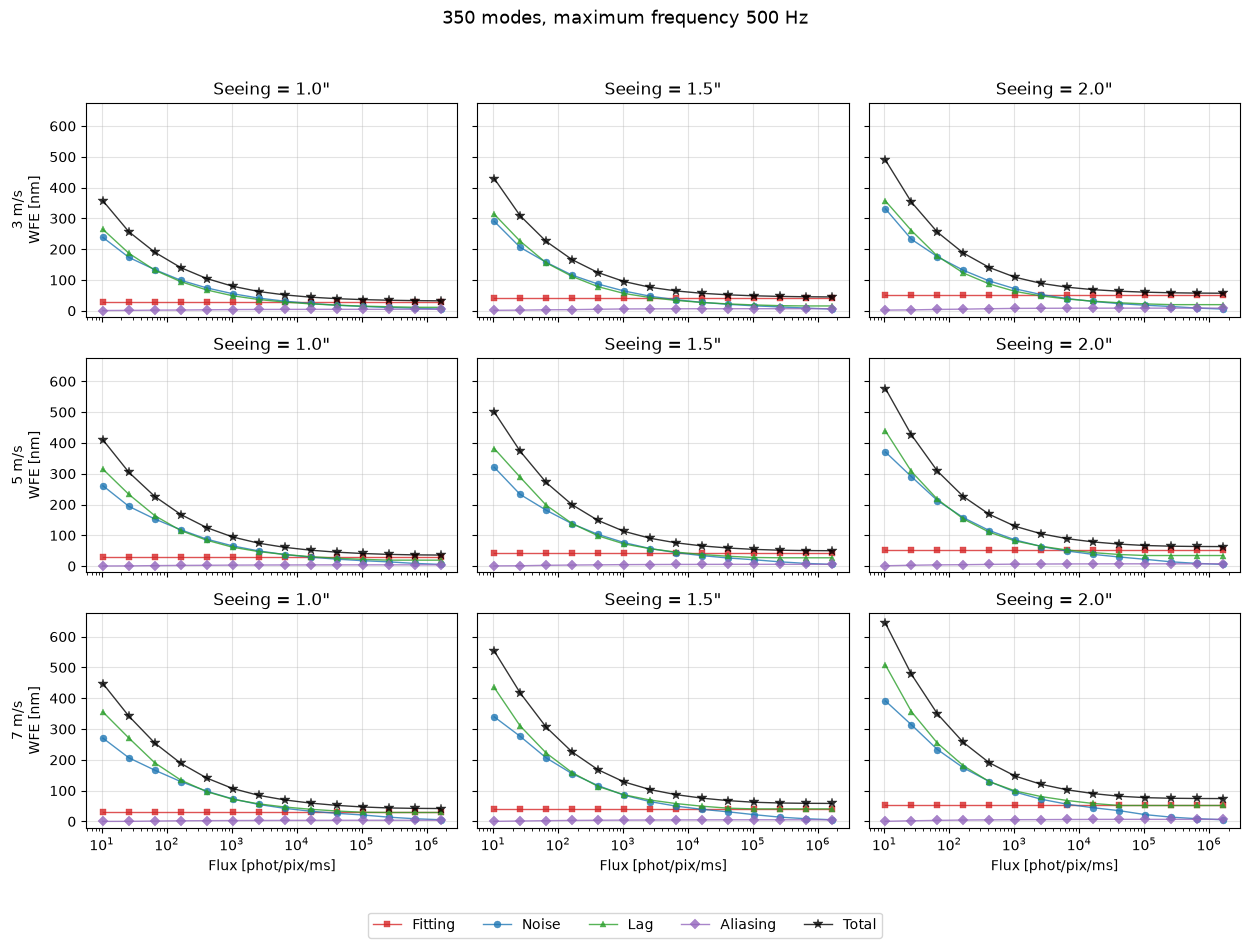

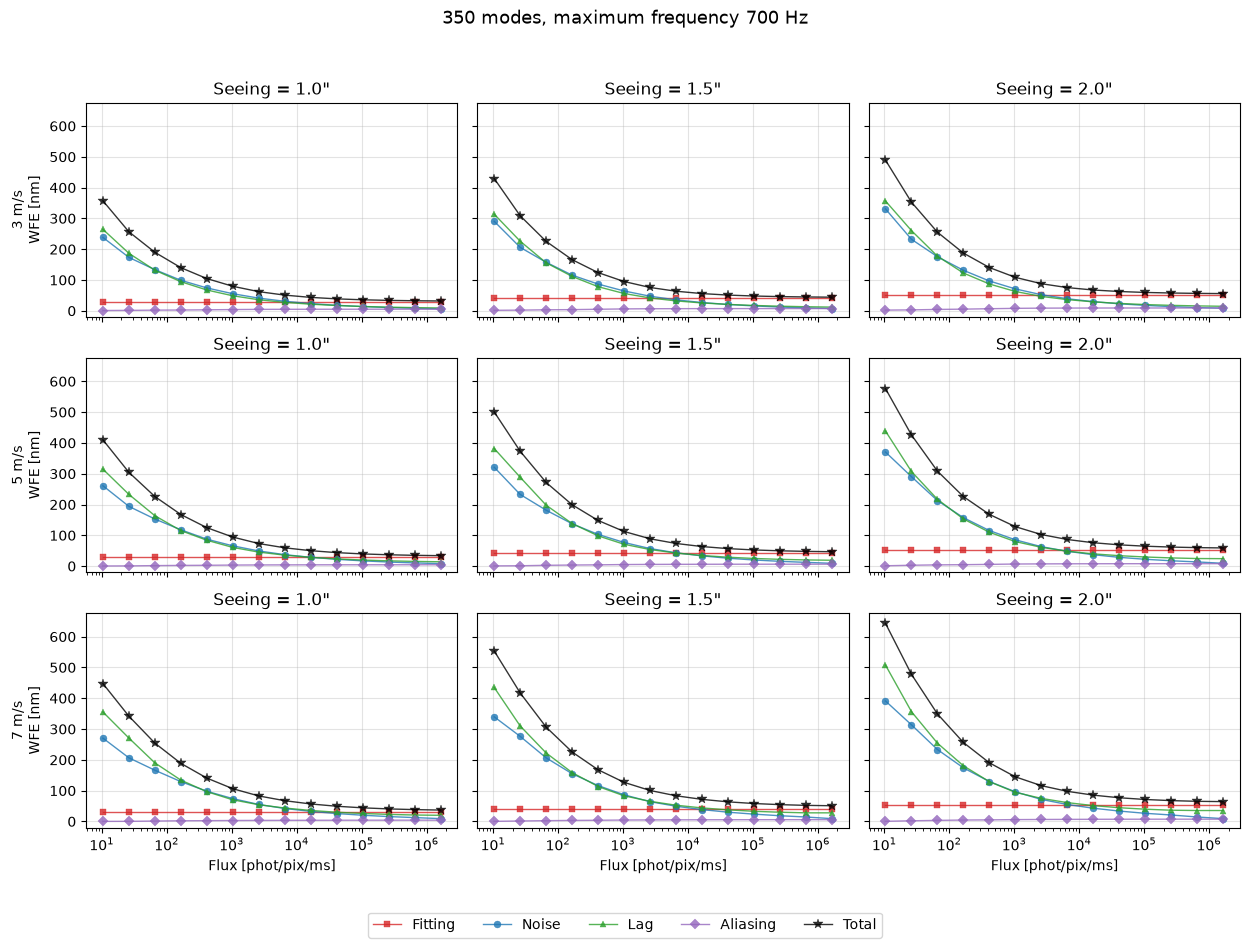

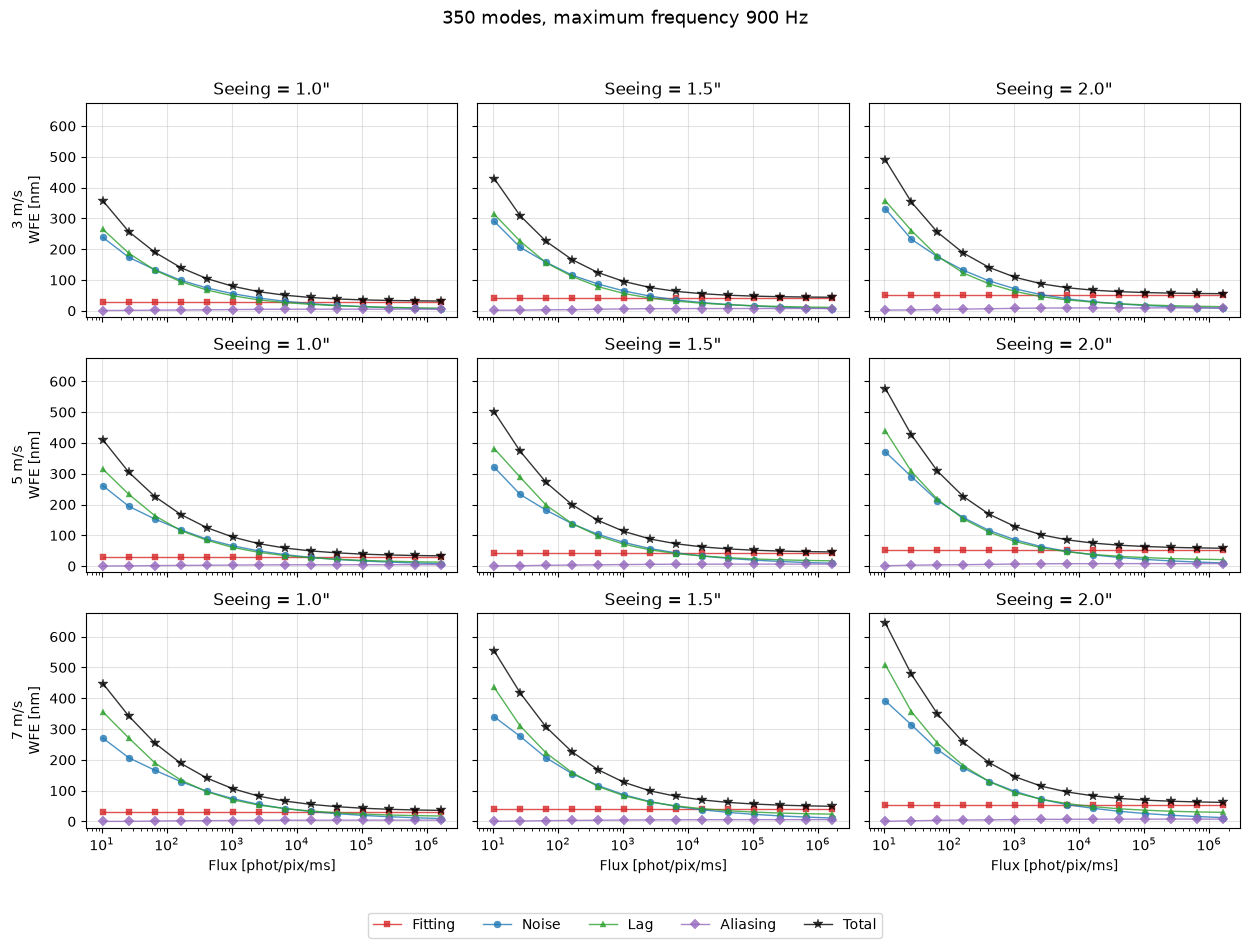

In [ ]:
from __future__ import annotations

import csv
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("/raid1/mmenessini/results/EKARUS/eb_csv")

def get_flux(mag:float, B0=10**10):
    thrp = 0.08
    area = np.pi/4*1.82**2*(1-0.32**2)
    return area * thrp * B0 * 10**(-mag/2.5)

N_PIX = 38**2*np.pi/4*(1-0.32**2)

# Columns are seeing, rows are wind speed.
REQUESTED_SEEINGS = (1.0, 1.5, 2.0)
REQUESTED_WINDS = (3.0, 5.0, 7.0)

SERIES = (
    ("Fitting", "fit", "s", "#d62728"),
    ("Noise", "noise", "o", "#1f77b4"),
    ("Lag", "lag", "^", "#2ca02c"),
    ("Aliasing", "alias", "D", "#9467bd"),
    ("Total", "total", "*", "black"),
)

_KEY_GROUPS = {
    "fit": ("fittingerror", "fit", "fitting", "wfefit"),
    "noise": ("noiseerror", "noise", "wfen"),
    "lag": ("lagerror", "lag", "servo", "wfes"),
    "alias": ("aliasingerror", "alias", "aliasing", "wfeal"),
    "magnitude": ("magnitude", "mag", "mags"),
    "seeing": ("seeing", "seeings"),
    "wind": ("wind", "windspeed", "v"),
    "photons": ("bestflux", "flux", "photons", "nph"),
    "frequency": ("bestfrequency", "frequency", "freq"),
    "fmax": ("maxfrequency", "maximumfrequency", "maxfreq", "fmax"),
    "nmodes": ("nmodes", "nmode", "modes"),
}

_SUFFIXES = {".csv", ".npy", ".npz", ".pkl", ".pickle"}
# eb_ekarus_rMod{rMod:1.1f}_max{maxFreq}Hz_{nmodes}modes_delay{tau*1e+3:1.2f}ms_V{windSpeed}mps
_CSV_NAME = re.compile(
    r"^eb_ekarus_rMod(?P<rmod>\d+\.\d)_max(?P<fmax>\d+(?:\.\d+)?)Hz_(?P<nmodes>\d+)modes_delay(?P<delay>\d+\.\d{2})ms_V(?P<wind>\d+(?:\.\d+)?)mps$",
    re.I,
)
_TEXT_ROLES = (
    ("nmodes", re.compile(r"(\d+(?:\.\d+)?)\s*modes", re.I)),
    (
        "fmax",
        re.compile(
            r"(?:max(?:imum)?[\s_-]*freq(?:uency)?[\s_-]*|fmax[\s_-]*|(?<![A-Za-z])max)(\d+(?:\.\d+)?)(?:Hz)?",
            re.I,
        ),
    ),
    ("wind", re.compile(r"(?:wind(?:[\s_-]*speed)?|(?<![A-Za-z])V)[\s_-]*(\d+(?:\.\d+)?)", re.I)),
    ("seeing", re.compile(r"seeing[\s_-]*(\d+(?:\.\d+)?)", re.I)),
    ("rmod", re.compile(r"rMod(\d+\.\d)", re.I)),
    ("delay_ms", re.compile(r"delay(\d+\.\d{2})ms", re.I)),
)


class Curve:
    def __init__(self, nmodes, fmax, wind, seeing, magnitude, photons, fit, noise, lag, alias, frequency):
        self.nmodes = None if nmodes is None else float(nmodes)
        self.fmax = None if fmax is None else float(fmax)
        self.wind = None if wind is None else float(wind)
        self.seeing = None if seeing is None else float(seeing)
        self.magnitude = _finite_vector(magnitude)
        self.photons = _finite_vector(photons)
        self.fit = np.asarray(fit, dtype=float).ravel()
        self.noise = np.asarray(noise, dtype=float).ravel()
        self.lag = np.asarray(lag, dtype=float).ravel()
        self.alias = np.asarray(alias, dtype=float).ravel()
        self.frequency = _finite_vector(frequency)


def _norm_key(key):
    return re.sub(r"[^a-z0-9]", "", str(key).lower())


def _finite_vector(value):
    if value is None:
        return None
    return np.asarray(value, dtype=float).ravel()


def _take(mapping, role):
    wanted = set(_KEY_GROUPS[role])
    for key, value in mapping.items():
        if _norm_key(key) in wanted:
            return value
    return None


def _classify_values(values):
    vals = np.asarray(list(values), dtype=float)
    if vals.size == 0 or not np.all(np.isfinite(vals)):
        return None
    if np.all(vals <= 2.5):
        return "seeing"
    if np.all((vals >= 2.5) & (vals <= 40.0)):
        return "wind"
    if np.all(vals >= 400.0):
        return "fmax"
    if np.all((vals >= 50.0) & (vals < 400.0)):
        return "nmodes"
    return None


def _roles_in_text(text):
    found = {}
    for role, pattern in _TEXT_ROLES:
        match = pattern.search(text)
        if match:
            found[role] = float(match.group(1))
    if not found and re.fullmatch(r"\d+(?:\.\d+)?", text):
        value = float(text)
        role = _classify_values([value])
        if role:
            found[role] = value
    return found


def _context_from_path(path, root):
    ctx = {}
    match = _CSV_NAME.match(path.stem)
    if match:
        ctx["rmod"] = float(match.group("rmod"))
        ctx["fmax"] = float(match.group("fmax"))
        ctx["nmodes"] = float(match.group("nmodes"))
        ctx["delay_ms"] = float(match.group("delay"))
        ctx["wind"] = float(match.group("wind"))
        return ctx
    for role, value in _roles_in_text(path.stem).items():
        ctx[role] = value
    for part in path.relative_to(root).parent.parts:
        for role, value in _roles_in_text(part).items():
            ctx.setdefault(role, value)
    return ctx


def _unwrap(obj):
    if isinstance(obj, np.ndarray) and obj.shape == ():
        try:
            return _unwrap(obj.item())
        except ValueError:
            return obj
    return obj


def _is_table(obj):
    if not isinstance(obj, dict) or not obj:
        return False
    keys = {_norm_key(key) for key in obj}
    return any(name in keys for name in _KEY_GROUPS["fit"] + _KEY_GROUPS["noise"] + _KEY_GROUPS["lag"] + _KEY_GROUPS["alias"])


def _role_of_mapping_keys(keys):
    labeled = False
    values = []
    for key in keys:
        found = _roles_in_text(str(key).strip()) if not isinstance(key, (int, float, np.integer, np.floating)) else {}
        if found:
            labeled = True
            continue
        if isinstance(key, (int, float, np.integer, np.floating)) and np.isfinite(key):
            values.append(float(key))
            continue
        try:
            values.append(float(str(key).strip()))
        except (TypeError, ValueError):
            return None
    if labeled or len(values) != len(list(keys)):
        return None
    return _classify_values(values)


def _apply_mapping_key(ctx, key, role):
    child = dict(ctx)
    if isinstance(key, (int, float, np.integer, np.floating)) and np.isfinite(key):
        found = {}
        value = float(key)
    else:
        found = _roles_in_text(str(key).strip())
        value = None
        if not found:
            try:
                value = float(str(key).strip())
            except (TypeError, ValueError):
                value = None
    if found:
        child.update(found)
    elif role and value is not None:
        child[role] = value
    return child


def _scalar_from(mapping, role, ctx):
    value = _take(mapping, role)
    if value is None:
        return ctx.get(role)
    arr = np.asarray(value, dtype=float).ravel()
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return ctx.get(role)
    if np.nanmax(finite) - np.nanmin(finite) < 1e-6:
        return float(finite[0])
    return ctx.get(role)


def _orient_grid(array, n_seeing, n_mag):
    array = np.asarray(array, dtype=float)
    if array.shape == (n_seeing, n_mag):
        return array
    if array.shape == (n_mag, n_seeing):
        return array.T
    return None


def _curves_from_table(table, ctx):
    fit = _take(table, "fit")
    noise = _take(table, "noise")
    lag = _take(table, "lag")
    alias = _take(table, "alias")
    if fit is None or noise is None or lag is None or alias is None:
        return []
    fit = np.asarray(fit, dtype=float)
    noise = np.asarray(noise, dtype=float)
    lag = np.asarray(lag, dtype=float)
    alias = np.asarray(alias, dtype=float)
    nmodes = _scalar_from(table, "nmodes", ctx)
    fmax = _scalar_from(table, "fmax", ctx)
    seeing = _take(table, "seeing")
    magnitude = _take(table, "magnitude")
    photons = _take(table, "photons")
    frequency = _take(table, "frequency")
    wind = _take(table, "wind")

    if fit.ndim == 2:
        if seeing is None or magnitude is None:
            print("Skipping a dictionary grid that has no seeing and magnitude axes")
            return []
        seeing = np.asarray(seeing, dtype=float).ravel()
        magnitude = np.asarray(magnitude, dtype=float).ravel()
        fit = _orient_grid(fit, seeing.size, magnitude.size)
        noise = _orient_grid(noise, seeing.size, magnitude.size)
        lag = _orient_grid(lag, seeing.size, magnitude.size)
        alias = _orient_grid(alias, seeing.size, magnitude.size)
        if fit is None or noise is None or lag is None or alias is None:
            print("Skipping a dictionary grid whose error arrays do not match seeing and magnitude")
            return []
        n_seeing, n_mag = fit.shape
        seeing_long = np.repeat(seeing, n_mag)
        mag_long = np.tile(magnitude, n_seeing)
        photons_long = _expand_like(photons, n_seeing, n_mag, ctx=None)
        freq_long = _expand_like(frequency, n_seeing, n_mag, ctx=None)
        wind_long = _expand_wind(wind, n_seeing, n_mag, ctx.get("wind"))
        return _group_long(nmodes, fmax, wind_long, seeing_long, mag_long, photons_long, fit.ravel(), noise.ravel(), lag.ravel(), alias.ravel(), freq_long)

    n = int(fit.size)
    series = {
        "fit": fit.ravel(),
        "noise": noise.ravel(),
        "lag": lag.ravel(),
        "alias": alias.ravel(),
    }
    if any(arr.size != n for arr in series.values()):
        print("Skipping a table whose residual columns have different lengths")
        return []
    mag_long = _match_length(magnitude, n)
    photons_long = _match_length(photons, n)
    freq_long = _match_length(frequency, n)
    seeing_long = _match_length(seeing, n)
    if seeing_long is None and ctx.get("seeing") is not None:
        seeing_long = np.full(n, float(ctx["seeing"]))
    wind_long = _match_length(wind, n)
    if wind_long is None and ctx.get("wind") is not None:
        wind_long = np.full(n, float(ctx["wind"]))
    return _group_long(nmodes, fmax, wind_long, seeing_long, mag_long, photons_long, series["fit"], series["noise"], series["lag"], series["alias"], freq_long)


def _match_length(value, n):
    if value is None:
        return None
    arr = np.asarray(value, dtype=float).ravel()
    if arr.size == 1:
        return np.full(n, float(arr[0]))
    if arr.size != n:
        return None
    return arr


def _expand_like(value, n_seeing, n_mag, ctx):
    if value is None:
        return None
    array = np.asarray(value, dtype=float)
    grid = _orient_grid(array, n_seeing, n_mag)
    if grid is not None:
        return grid.ravel()
    if array.size == 1:
        return np.full(n_seeing * n_mag, float(array.ravel()[0]))
    if array.ndim == 1 and array.size == n_mag:
        return np.tile(array, n_seeing)
    if array.ndim == 1 and array.size == n_seeing:
        return np.repeat(array, n_mag)
    return None


def _expand_wind(value, n_seeing, n_mag, fallback):
    expanded = _expand_like(value, n_seeing, n_mag, None)
    if expanded is not None:
        return expanded
    if fallback is None:
        return None
    return np.full(n_seeing * n_mag, float(fallback))


def _group_long(nmodes, fmax, wind, seeing, magnitude, photons, fit, noise, lag, alias, frequency):
    if seeing is None or wind is None:
        return []
    n = fit.size
    if any(arr is not None and arr.size != n for arr in (seeing, wind, magnitude, photons, frequency, noise, lag, alias)):
        print("Skipping a table whose columns do not share a length")
        return []
    curves = []
    winds = np.unique(wind[np.isfinite(wind)])
    seeings = np.unique(seeing[np.isfinite(seeing)])
    for wind_value in winds:
        for seeing_value in seeings:
            mask = (np.abs(wind - wind_value) <= 1e-6) & (np.abs(seeing - seeing_value) <= 1e-6)
            if not np.any(mask):
                continue
            curves.append(
                Curve(
                    nmodes,
                    fmax,
                    wind_value,
                    seeing_value,
                    None if magnitude is None else magnitude[mask],
                    None if photons is None else photons[mask],
                    fit[mask],
                    noise[mask],
                    lag[mask],
                    alias[mask],
                    None if frequency is None else frequency[mask],
                )
            )
    return curves


def _walk(obj, ctx, out):
    obj = _unwrap(obj)
    if _is_table(obj):
        out.extend(_curves_from_table(obj, ctx))
        return
    if isinstance(obj, dict):
        role = _role_of_mapping_keys(obj.keys())
        for key, value in obj.items():
            _walk(value, _apply_mapping_key(ctx, key, role), out)
        return
    if isinstance(obj, (list, tuple)):
        for value in obj:
            _walk(value, ctx, out)


def _load_file(path, ctx):
    suffix = path.suffix.lower()
    out = []
    if suffix == ".csv":
        out.extend(_curves_from_table(_read_csv(path), ctx))
    elif suffix == ".npy":
        _walk(np.load(path, allow_pickle=True), ctx, out)
    elif suffix == ".npz":
        with np.load(path, allow_pickle=True) as archive:
            _walk({name: archive[name] for name in archive.files}, ctx, out)
    elif suffix in {".pkl", ".pickle"}:
        with path.open("rb") as handle:
            _walk(pickle.load(handle), ctx, out)
    return out


def _read_csv(path):
    with path.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        rows = list(reader)
        fieldnames = reader.fieldnames or []
    if not rows:
        return {}
    data = {}
    for name in fieldnames:
        values = []
        numeric = True
        for row in rows:
            raw = (row.get(name) or "").strip()
            if raw == "" or raw.lower() == "nan":
                values.append(np.nan)
                continue
            try:
                values.append(float(raw))
            except ValueError:
                numeric = False
                break
        if numeric:
            data[name] = np.asarray(values, dtype=float)
    return data


def _scale_to_nm(curve):
    stacked = np.concatenate([curve.fit, curve.noise, curve.lag, curve.alias])
    finite = stacked[np.isfinite(stacked)]
    if finite.size and np.nanmedian(np.abs(finite)) < 1e-3:
        curve.fit = curve.fit * 1e9
        curve.noise = curve.noise * 1e9
        curve.lag = curve.lag * 1e9
        curve.alias = curve.alias * 1e9
        return True
    return False


def load_error_budget(root):
    """Load every error-budget table under the results directory."""
    root = Path(root)
    if not root.is_dir():
        raise FileNotFoundError(f"Error-budget directory not found: {root}")
    files = sorted(path for path in root.rglob("*") if path.is_file() and path.suffix.lower() in _SUFFIXES)
    csv_files = [path for path in files if path.suffix.lower() == ".csv"]
    other_files = [path for path in files if path.suffix.lower() != ".csv"]
    matched = []
    for path in csv_files:
        if _CSV_NAME.match(path.stem):
            matched.append(path)
        else:
            print(f"Skipping {path.name}: CSV name is not eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps")
    files = matched + other_files
    if not files:
        raise FileNotFoundError(
            f"No eb_ekarus_rMod*_max*Hz_*modes_delay*ms_V*mps.csv or dictionary files in {root}"
        )
    curves = []
    converted = 0
    for path in files:
        try:
            found = _load_file(path, _context_from_path(path, root))
        except (OSError, ValueError, pickle.UnpicklingError, csv.Error) as exc:
            print(f"Skipping {path.name}: {exc}")
            continue
        for curve in found:
            if curve.wind is None or curve.seeing is None:
                print(f"Skipping a block in {path.name}: wind speed or seeing is not in the table")
                continue
            converted += int(_scale_to_nm(curve))
            curves.append(curve)
    if converted:
        print(f"Interpreted {converted} curves as metres and scaled them to nm")
    else:
        print("Residuals are used as stored, in nm")
    print(f"{len(curves)} seeing/wind curves from {len(files)} files in {root}")
    if not curves:
        raise RuntimeError(f"No usable seeing/wind curves in {root}")
    return curves


def _closest(requested, available):
    if not available:
        return None
    values = np.asarray(sorted(available), dtype=float)
    return float(values[np.argmin(np.abs(values - requested))])


def _fmt_seeing(value):
    return f"{value:.1f}"


def _fmt_wind(value):
    return f"{value:g}"


def _max_frequency(curves):
    explicit = [curve.fmax for curve in curves if curve.fmax is not None]
    if explicit:
        return float(np.max(explicit)), True
    peaks = []
    for curve in curves:
        if curve.frequency is None:
            continue
        finite = curve.frequency[np.isfinite(curve.frequency)]
        if finite.size:
            peaks.append(float(np.max(finite)))
    if not peaks:
        return None, False
    return float(np.max(peaks)), False


def _flux_per_pixel(curve):
    if curve.magnitude is not None:
        return np.asarray(get_flux(curve.magnitude), dtype=float) / N_PIX
    if curve.photons is not None:
        return np.asarray(curve.photons, dtype=float) / N_PIX
    return None


def _xy(curve, use_magnitude=False):
    x = _flux_per_pixel(curve)
    label = "Flux [phot/pix/ms]"
    log_x = True
    if x is None:
        return None, label, log_x
    y = {
        "fit": curve.fit,
        "noise": curve.noise,
        "lag": curve.lag,
        "alias": curve.alias,
        "total": np.sqrt(curve.fit**2 + curve.noise**2 + curve.lag**2 + curve.alias**2),
    }
    return x, y, label, log_x


def _plot_series(ax, curves, use_magnitude, label_once):
    drew = False
    pieces = []
    for curve in curves:
        packed = _xy(curve, use_magnitude)
        if packed[0] is None:
            continue
        x, y, _label, _log = packed
        pieces.append((np.asarray(x, dtype=float).ravel(), y))
    if not pieces:
        return False
    for name, key, marker, color in SERIES:
        xs = []
        ys = []
        for x, ymap in pieces:
            y = np.asarray(ymap[key], dtype=float).ravel()
            n = min(x.size, y.size)
            xs.append(x[:n])
            ys.append(y[:n])
        x = np.concatenate(xs)
        y = np.concatenate(ys)
        order = np.argsort(x)
        x = x[order]
        y = y[order]
        mask = np.isfinite(x) & np.isfinite(y)
        if not use_magnitude:
            mask = mask & (x > 0)
        style = dict(
            linestyle="-",
            marker=marker,
            color=color,
            markersize=7 if marker == "*" else 5,
            linewidth=1.,
            markeredgewidth=0.3,
            alpha=0.8,
            markeredgecolor=color,
        )
        if np.any(mask):
            ax.plot(x[mask], y[mask], label=name if label_once else None, **style)
            drew = True
        elif label_once:
            ax.plot([], [], label=name, **style)
    return drew


def plot_error_budget(curves):
    """One 3×3 figure for each stored (mode count, maximum frequency) pair."""
    groups = {}
    for curve in curves:
        groups.setdefault((curve.nmodes, curve.fmax), []).append(curve)
    figures = []
    for (nmodes, explicit_fmax) in sorted(groups, key=lambda item: ((item[0] is None, item[0] or 0), (item[1] is None, item[1] or 0))):
        group = groups[(nmodes, explicit_fmax)]
        fmax, explicit = _max_frequency(group)
        use_magnitude = False
        winds = {curve.wind for curve in group}
        seeings = {curve.seeing for curve in group}
        notes = []
        fig, axes = plt.subplots(3, 3, figsize=(12.6, 9.4), sharex=True, sharey=True, squeeze=False)
        labeled = False
        finite_y = []
        for row, requested_wind in enumerate(REQUESTED_WINDS):
            used_wind = _closest(requested_wind, winds)
            if used_wind is None:
                wind_text = f"{_fmt_wind(requested_wind)} m/s"
            elif abs(used_wind - requested_wind) > 1e-3:
                wind_text = f"{_fmt_wind(requested_wind)} m/s\n(using {_fmt_wind(used_wind)} m/s)"
                notes.append(f"wind {_fmt_wind(used_wind)} m/s is the closest stored value to {_fmt_wind(requested_wind)} m/s")
            else:
                wind_text = f"{_fmt_wind(requested_wind)} m/s"
            for col, requested_seeing in enumerate(REQUESTED_SEEINGS):
                ax = axes[row, col]
                used_seeing = _closest(requested_seeing, seeings)
                if used_seeing is None:
                    title = f"Seeing = {_fmt_seeing(requested_seeing)}\""
                elif abs(used_seeing - requested_seeing) > 1e-3:
                    title = f"Seeing = {_fmt_seeing(used_seeing)}\" (closest to {_fmt_seeing(requested_seeing)}\")"
                    notes.append(
                        f"seeing {_fmt_seeing(used_seeing)}\" is the closest stored value to {_fmt_seeing(requested_seeing)}\""
                    )
                else:
                    title = f"Seeing = {_fmt_seeing(requested_seeing)}\""
                ax.set_title(title)
                ax.grid(True, alpha=0.35)
                ax.set_axisbelow(True)
                selected = []
                if used_wind is not None and used_seeing is not None:
                    selected = [
                        curve
                        for curve in group
                        if abs(curve.wind - used_wind) <= 1e-3 and abs(curve.seeing - used_seeing) <= 1e-3
                    ]
                plotted = False
                if selected:
                    plotted = _plot_series(ax, selected, use_magnitude, label_once=not labeled)
                    labeled = labeled or plotted
                if not plotted:
                    ax.grid(False)
                else:
                    for line in ax.get_lines():
                        finite_y.append(line.get_ydata())
                if col == 0:
                    ax.set_ylabel(f"{wind_text}\nWFE [nm]")
                if row == 2:
                    ax.set_xlabel("Flux [phot/pix/ms]")
                if plotted and not use_magnitude:
                    ax.set_xscale("log")
                    ax.set_yscale("log")
        if finite_y:
            stacked = np.concatenate(finite_y)
            stacked = stacked[np.isfinite(stacked)]
            if stacked.size and np.min(stacked) >= 0:
                axes[0, 0].set_ylim(bottom=-20)
        if nmodes is None:
            mode_text = "mode count not stored"
        else:
            mode_text = f"{nmodes:g} modes"
        if fmax is None:
            freq_text = "maximum frequency not stored"
        else:
            freq_text = f"maximum frequency {fmax:g} Hz"
        title = f"{mode_text}, {freq_text}"
        unique_notes = list(dict.fromkeys(notes))
        if unique_notes:
            lines = []
            current = ""
            for note in unique_notes:
                piece = note if not current else "; " + note
                if current and len(current) + len("; " + note) > 110:
                    lines.append(current)
                    current = note
                else:
                    current = piece
            if current:
                lines.append(current)
            title = title + "\n" + "\n".join(lines)
        title_lines = title.count("\n") + 1
        axes_top = 0.97 - 0.04 * (title_lines - 1)
        fig.suptitle(title, fontsize=13, y=0.995)
        handles, labels = [], []
        for ax in axes.ravel():
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                break
        if handles:
            fig.legend(
                handles,
                labels,
                loc="lower center",
                ncol=5,
                frameon=True,
                bbox_to_anchor=(0.5, 0.0),
            )
        fig.tight_layout(rect=(0, 0.06, 1, axes_top))
        figures.append(fig)
        print(title.replace("\n", " | "))
    return figures


curves = load_error_budget(DATA_DIR)
plot_error_budget(curves)
plt.show()


## 650 nm Strehl

One 3×3 figure overlays the Strehl curves for `(200, 500)`, `(200, 900)`, `(350, 500)` and `(350, 900)` modes and hertz. The atmospheric grid matches the residual figures, and the x-axis is flux in phot/pix/ms.

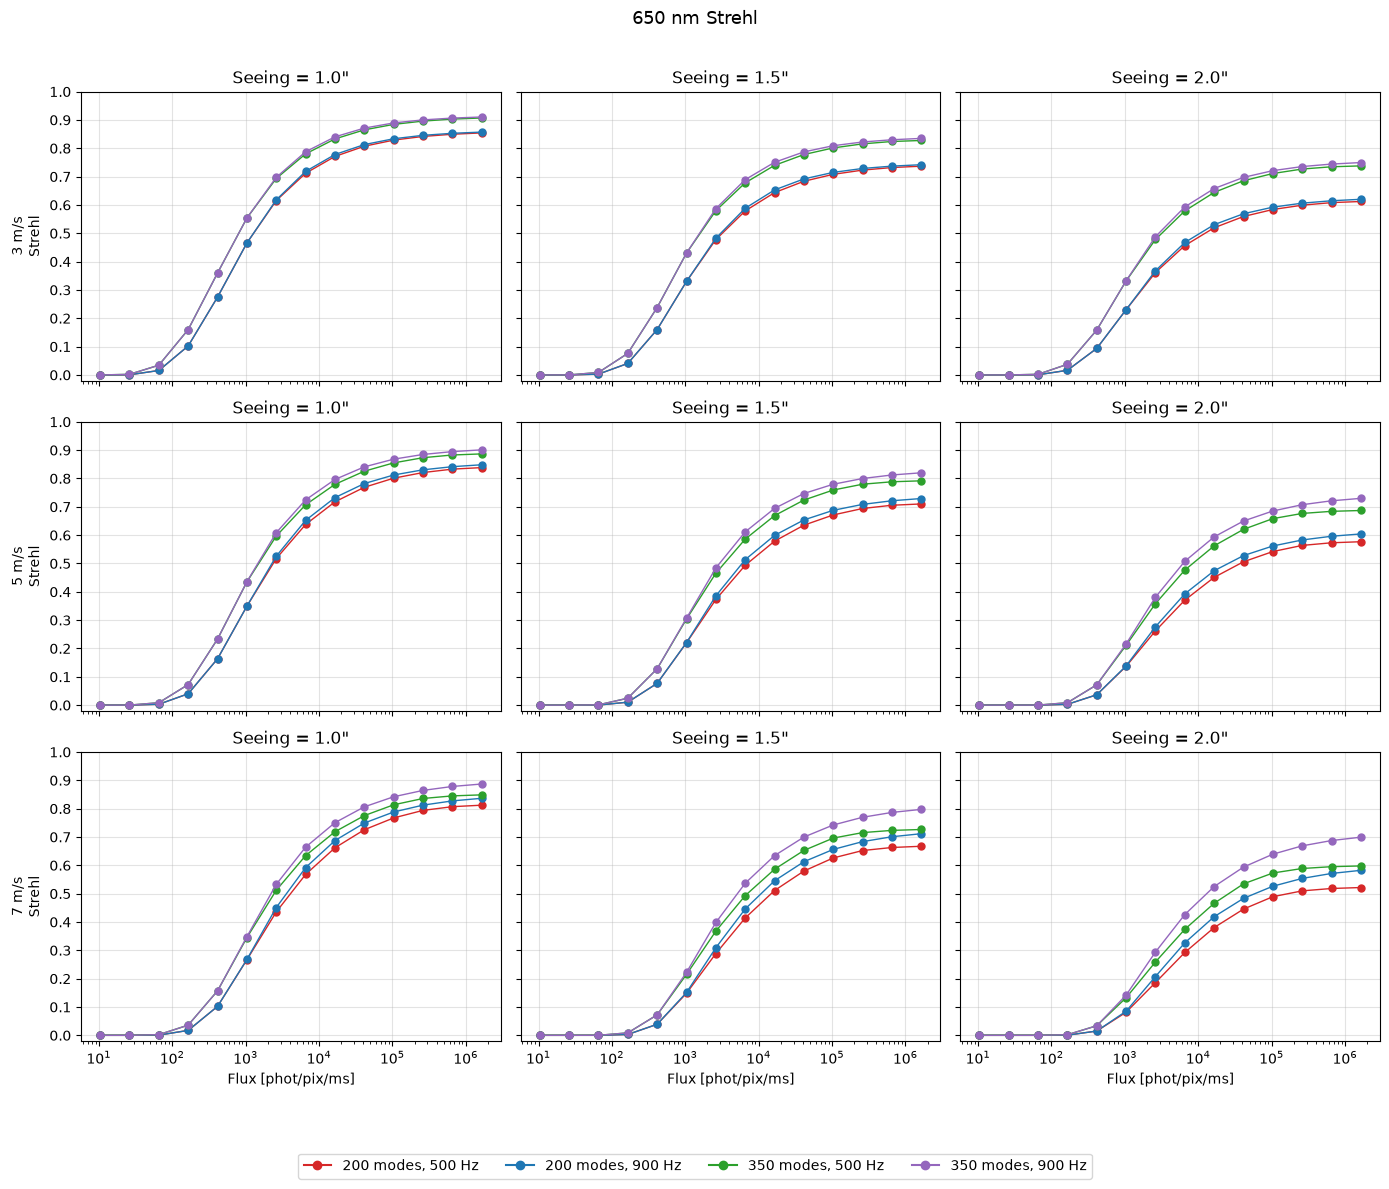

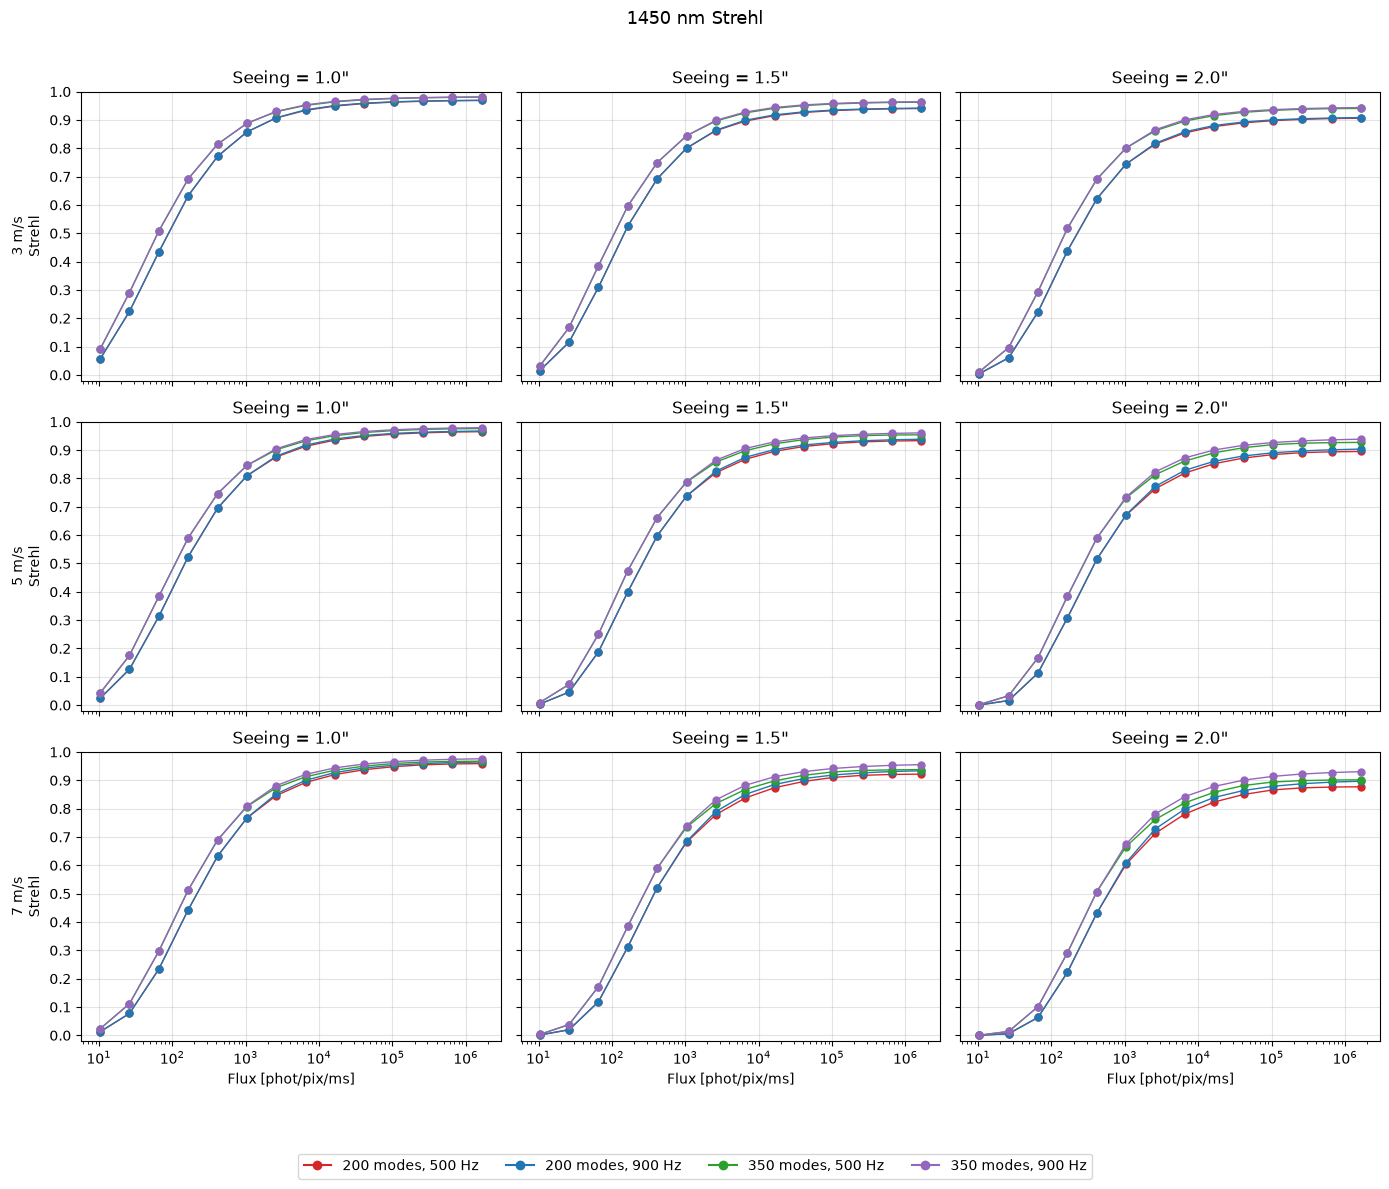

In [ ]:
# 650 nm Strehl on the same seeing / wind grid.
# Strehl = exp(-sigma**2), sigma = 2*pi*res_tot/lambda, lambda = 650 nm.

from matplotlib.lines import Line2D


STREHL_CASES = ((200, 500), (200, 900), (350, 500), (350, 900))
STREHL_COLORS = ("#d62728", "#1f77b4", "#2ca02c", "#9467bd")


def _case_curves(curves, nmodes, fmax):
    return [
        curve
        for curve in curves
        if curve.nmodes is not None
        and curve.fmax is not None
        and abs(curve.nmodes - nmodes) <= 1e-6
        and abs(curve.fmax - fmax) <= 1e-6
    ]


def _strehl(fit, noise, lag, alias, lambdaNm=650):
    res_nm = np.sqrt(
        np.asarray(fit, dtype=float) ** 2
        + np.asarray(noise, dtype=float) ** 2
        + np.asarray(lag, dtype=float) ** 2
        + np.asarray(alias, dtype=float) ** 2
    )
    sigma = 2 * np.pi * res_nm / lambdaNm
    return np.exp(-(sigma ** 2))


def plot_strehl(curves, lambdaNm=650):
    """Overlay all requested mode/frequency cases in one 3x3 figure."""
    fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True, squeeze=False)
    cases = [
        (nmodes, fmax, _case_curves(curves, nmodes, fmax), color)
        for (nmodes, fmax), color in zip(STREHL_CASES, STREHL_COLORS)
    ]

    for row, requested_wind in enumerate(REQUESTED_WINDS):
        for col, requested_seeing in enumerate(REQUESTED_SEEINGS):
            ax = axes[row, col]
            ax.set_title(f"Seeing = {_fmt_seeing(requested_seeing)}\"")
            ax.grid(True, alpha=0.35)
            ax.set_axisbelow(True)
            drew = False

            for nmodes, fmax, group, color in cases:
                winds = {curve.wind for curve in group}
                seeings = {curve.seeing for curve in group}
                used_wind = _closest(requested_wind, winds)
                used_seeing = _closest(requested_seeing, seeings)
                if used_wind is None or used_seeing is None:
                    continue
                selected = [
                    curve
                    for curve in group
                    if abs(curve.wind - used_wind) <= 1e-3
                    and abs(curve.seeing - used_seeing) <= 1e-3
                ]
                for curve in selected:
                    x = _flux_per_pixel(curve)
                    if x is None:
                        continue
                    y = _strehl(curve.fit, curve.noise, curve.lag, curve.alias, lambdaNm=lambdaNm)
                    x = np.asarray(x, dtype=float).ravel()
                    y = np.asarray(y, dtype=float).ravel()
                    n = min(x.size, y.size)
                    x = x[:n]
                    y = y[:n]
                    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
                    if np.any(mask):
                        ax.plot(
                            x[mask],
                            y[mask],
                            linestyle="-",
                            marker="o",
                            color=color,
                            markersize=5,
                            linewidth=1.,
                        )
                        ax.set_yticks(np.arange(11)*0.1)
                        drew = True
                # ax.plot([2**14,2**14],[-1,2],'--',c='r')

            if not drew:
                ax.grid(False)
            else:
                ax.set_xscale("log")
            if col == 0:
                ax.set_ylabel(f"{_fmt_wind(requested_wind)} m/s\nStrehl")
            if row == 2:
                ax.set_xlabel("Flux [phot/pix/ms]")

    axes[0, 0].set_ylim(-0.02, 1)
    fig.suptitle(f"{lambdaNm:1.0f} nm Strehl", fontsize=13)
    handles = [
        Line2D(
            [],
            [],
            color=color,
            marker="o",
            linestyle="-",
            label=f"{nmodes} modes, {fmax} Hz",
        )
        for (nmodes, fmax), color in zip(STREHL_CASES, STREHL_COLORS)
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=True, bbox_to_anchor=(0.5, 0.0))
    fig.tight_layout(rect=(0, 0.07, 1, 0.97))
    return fig


strehl_fig = plot_strehl(curves, lambdaNm=650)
# strehl_fig = plot_strehl(curves, lambdaNm=1450)